In [1]:
#  IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import re
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# FIFA WORLD CUP 2026
# LINEAR REGRESSION 2.1
# LOAD EXCEL FILE
file_path = "104_world_cup_dataset.xlsx"

df1 = pd.read_excel(
    file_path,
    sheet_name="Worksheet"
)

df2 = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

print("Original Worksheet shape:", df1.shape)
print("Original Sheet1 shape:", df2.shape)

Original Worksheet shape: (107, 13)
Original Sheet1 shape: (104, 6)


In [3]:
#  REMOVE COMPLETELY EMPTY ROWS
df1 = df1.dropna(
    how="all"
).reset_index(drop=True)

df2 = df2.dropna(
    how="all"
).reset_index(drop=True)

print("\nWorksheet shape after cleaning:", df1.shape)
print("Sheet1 shape after cleaning:", df2.shape)


Worksheet shape after cleaning: (104, 13)
Sheet1 shape after cleaning: (104, 6)


In [4]:
# DISPLAY ORIGINAL COLUMNS
print("WORKSHEET COLUMNS")
for i, col in enumerate(df1.columns, start=1):
    print(f"{i}. {col}")

print("SHEET1 COLUMNS")
for i, col in enumerate(df2.columns, start=1):
    print(f"{i}. {col}")

WORKSHEET COLUMNS
1. Round
2. Wk
3. Day
4. Date
5. Time
6. Home
7. Score
8. Away
9. Attendance
10. Venue
11. Referee
12. Match Report
13. Notes
SHEET1 COLUMNS
1. home_fifa_rank
2. away_fifa_rank
3. home_elo
4. away_elo
5. home_squad_avg_age
6. away_squad_avg_age


In [5]:
# FIX TEXT ENCODING
def fix_encoding(text):

    if pd.isna(text):
        return text

    text = str(text)

    replacements = {
        "â€“": "–",
        "â€”": "—",
        "â€˜": "'",
        "â€™": "'",
        "â€œ": '"',
        "â€": '"',
        "Ã©": "é",
        "Ã¨": "è",
        "Ã¼": "ü",
        "Ã¶": "ö",
        "Ã±": "ñ",
        "Ã§": "ç",
        "Ã³": "ó",
        "Ã¡": "á",
        "Ã­": "í",
        "Ãº": "ú",
        "Ã¥": "å",
        "Ä": "č",
        "Ä‡": "ć",
        "Å¡": "š",
        "Å¾": "ž"
    }

    for wrong, correct in replacements.items():
        text = text.replace(wrong, correct)

    return text


for col in df1.select_dtypes(
    include="object"
).columns:

    df1[col] = df1[col].apply(
        fix_encoding
    )


In [6]:
#  CLEAN TEAM NAMES
def clean_team_name(team):

    if pd.isna(team):
        return team

    team = str(team).strip()

    # Remove FIFA code from beginning
    team = re.sub(
        r"^[a-z]{2,3}\s+",
        "",
        team
    )

    # Remove FIFA code from end
    team = re.sub(
        r"\s+[a-z]{2,3}$",
        "",
        team
    )

    return team.strip()


df1["Home"] = df1["Home"].apply(
    clean_team_name
)

df1["Away"] = df1["Away"].apply(
    clean_team_name
)


In [7]:
#  EXTRACT HOME AND AWAY SCORES
def extract_score(score):

    if pd.isna(score):
        return pd.Series([np.nan, np.nan])

    score = str(score)

    match = re.search(
        r"(\d+)\s*[–—-]\s*(\d+)",
        score
    )

    if match:

        return pd.Series([
            int(match.group(1)),
            int(match.group(2))
        ])

    return pd.Series([
        np.nan,
        np.nan
    ])


df1[
    ["home_score", "away_score"]
] = df1["Score"].apply(
    extract_score
)

In [8]:
# SCORE CHECK
print("SCORE CHECK")

print(
    df1[
        [
            "Home",
            "Score",
            "Away",
            "home_score",
            "away_score"
        ]
    ].head(10)
)

SCORE CHECK
             Home Score          Away  home_score  away_score
0          Mexico   2–0  South Africa           2           0
1  Korea Republic   2–1       Czechia           2           1
2          Canada   1–1   Bosnia–Herz           1           1
3             USA   4–1      Paraguay           4           1
4           Qatar   1–1   Switzerland           1           1
5          Brazil   1–1       Morocco           1           1
6       Australia   2–0       Türkiye           2           0
7           Haiti   0–1      Scotland           0           1
8         Germany   7–1       Curaçao           7           1
9     Netherlands   2–2         Japan           2           2


In [9]:
#  CREATE TARGET VARIABLE
df1["goal_difference"] = (
    df1["home_score"]
    -
    df1["away_score"]
)



In [10]:
#  CREATE MATCH ID
df1["match_id"] = range(
    1,
    len(df1) + 1
)

df2["match_id"] = range(
    1,
    len(df2) + 1
)



In [11]:
#  CONVERT SHEET1 VARIABLES TO NUMERIC
base_predictors = [
    "home_fifa_rank",
    "away_fifa_rank",
    "home_elo",
    "away_elo",
    "home_squad_avg_age",
    "away_squad_avg_age"
]


for col in base_predictors:

    if col not in df2.columns:

        raise ValueError(
            f"Required column '{col}' "
            f"not found in Sheet1."
        )

    df2[col] = pd.to_numeric(
        df2[col],
        errors="coerce"
    )



In [12]:
#  CREATE TWO ADDITIONAL PRE-MATCH VARIABLES
# FIFA ranking difference

df2["fifa_rank_difference"] = (
    df2["home_fifa_rank"]
    -
    df2["away_fifa_rank"]
)

# Elo rating difference

df2["elo_difference"] = (
    df2["home_elo"]
    -
    df2["away_elo"]
)



In [13]:
#  MERGE THE TWO DATASETS
merged_df = pd.merge(
    df1,
    df2,
    on="match_id",
    how="inner"
)

print("MERGED DATASET")


print(
    "Rows:",
    len(merged_df)
)

if len(merged_df) != 104:

    raise ValueError(
        "Merged dataset must contain exactly "
        "104 matches."
    )

print(
    "Exactly 104 match observations."
)


MERGED DATASET
Rows: 104
Exactly 104 match observations.


In [14]:
# DEFINE EXACTLY 8 EXPLANATORY VARIABLES

explanatory_variables = [

    # 1
    "home_fifa_rank",

    # 2
    "away_fifa_rank",

    # 3
    "home_elo",

    # 4
    "away_elo",

    # 5
    "home_squad_avg_age",

    # 6
    "away_squad_avg_age",

    # 7
    "fifa_rank_difference",

    # 8
    "elo_difference"
]


target_variable = "goal_difference"



In [15]:
#  EXPLANATORY VARIABLE CHECK
print("EXPLANATORY VARIABLE CHECK")
print(
    "Number of explanatory variables:",
    len(explanatory_variables)
)

for i, variable in enumerate(
    explanatory_variables,
    start=1
):

    print(
        f"{i}. {variable}"
    )

if len(explanatory_variables) != 8:

    raise ValueError(
        "The dataset must contain exactly "
        "8 explanatory variables."
    )


EXPLANATORY VARIABLE CHECK
Number of explanatory variables: 8
1. home_fifa_rank
2. away_fifa_rank
3. home_elo
4. away_elo
5. home_squad_avg_age
6. away_squad_avg_age
7. fifa_rank_difference
8. elo_difference


In [16]:
#  CREATE FINAL REGRESSION DATASET


regression_21 = merged_df[
    [
        "match_id",

        # Eight explanatory variables
        "home_fifa_rank",
        "away_fifa_rank",
        "home_elo",
        "away_elo",
        "home_squad_avg_age",
        "away_squad_avg_age",
        "fifa_rank_difference",
        "elo_difference",

        # Outcome/reference variables
        "home_score",
        "away_score",

        # Target
        "goal_difference"
    ]
].copy()

In [17]:
#  CHECK FINAL DATASET

print("FINAL REGRESSION DATASET")


print(
    "Rows:",
    regression_21.shape[0]
)

print(
    "Columns:",
    regression_21.shape[1]
)

print("\nColumns:")

for i, col in enumerate(
    regression_21.columns,
    start=1
):

    print(
        f"{i}. {col}"
    )


FINAL REGRESSION DATASET
Rows: 104
Columns: 12

Columns:
1. match_id
2. home_fifa_rank
3. away_fifa_rank
4. home_elo
5. away_elo
6. home_squad_avg_age
7. away_squad_avg_age
8. fifa_rank_difference
9. elo_difference
10. home_score
11. away_score
12. goal_difference


In [18]:
# MISSING VALUE CHECK

print("MISSING VALUE CHECK")


missing_values = regression_21[
    [
        "match_id"
    ]
    +
    explanatory_variables
    +
    [
        "home_score",
        "away_score",
        "goal_difference"
    ]
].isnull().sum()

print(missing_values)


if missing_values.sum() > 0:

    raise ValueError(
        "Missing values detected. "
        "Check the dataset before modelling."
    )

print(
    "\n No missing values."
)



MISSING VALUE CHECK
match_id                0
home_fifa_rank          0
away_fifa_rank          0
home_elo                0
away_elo                0
home_squad_avg_age      0
away_squad_avg_age      0
fifa_rank_difference    0
elo_difference          0
home_score              0
away_score              0
goal_difference         0
dtype: int64

 No missing values.


In [19]:
# CHECK DUPLICATES

print("DUPLICATE CHECK")

duplicate_ids = (
    regression_21[
        "match_id"
    ].duplicated().sum()
)

print(
    "Duplicate match IDs:",
    duplicate_ids
)

if duplicate_ids > 0:

    raise ValueError(
        "Duplicate match IDs detected."
    )

print(
    " No duplicate match IDs."
)



DUPLICATE CHECK
Duplicate match IDs: 0
 No duplicate match IDs.


In [20]:
# DESCRIPTIVE STATISTICS
print("DESCRIPTIVE STATISTICS")
print(
    regression_21[
        explanatory_variables
        +
        ["goal_difference"]
    ].describe()
)



DESCRIPTIVE STATISTICS
       home_fifa_rank  away_fifa_rank     home_elo     away_elo  \
count      104.000000      104.000000   104.000000   104.000000   
mean        24.759615       31.759615  1867.980769  1810.961538   
std         22.219774       23.219717   172.016198   159.524592   
min          1.000000        1.000000  1510.000000  1510.000000   
25%          6.000000       11.000000  1740.000000  1687.500000   
50%         17.000000       25.500000  1850.000000  1797.500000   
75%         39.000000       51.000000  2010.000000  1920.000000   
max         85.000000       85.000000  2150.000000  2150.000000   

       home_squad_avg_age  away_squad_avg_age  fifa_rank_difference  \
count          104.000000          104.000000            104.000000   
mean            27.879854           27.852690             -7.000000   
std              1.080865            1.111936             33.654152   
min             25.848997           25.848997            -77.000000   
25%             26

In [21]:
#  DEFINE X AND Y

X = regression_21[
    explanatory_variables
].copy()

y = regression_21[
    target_variable
].copy()



In [22]:
#  TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAIN-TEST SPLIT")

print(
    "Training observations:",
    len(X_train)
)

print(
    "Testing observations:",
    len(X_test)
)


TRAIN-TEST SPLIT
Training observations: 83
Testing observations: 21


In [23]:
#  FIT LINEAR REGRESSION

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)


LinearRegression()

In [24]:
# COEFFICIENTS

print("LINEAR REGRESSION COEFFICIENTS")

coefficients = pd.DataFrame({

    "Variable":
        explanatory_variables,

    "Coefficient":
        linear_model.coef_

})

print(
    coefficients
)

print(
    "\nIntercept:",
    linear_model.intercept_
)


LINEAR REGRESSION COEFFICIENTS
               Variable  Coefficient
0        home_fifa_rank    -0.011708
1        away_fifa_rank    -0.024213
2              home_elo    -0.001393
3              away_elo    -0.005586
4    home_squad_avg_age    -0.030065
5    away_squad_avg_age     0.126964
6  fifa_rank_difference     0.012505
7        elo_difference     0.004193

Intercept: 11.438001909577618


In [25]:
#  PREDICTIONS
y_train_pred = linear_model.predict(
    X_train
)

y_test_pred = linear_model.predict(
    X_test
)



In [26]:
#  MODEL EVALUATION FUNCTION
def evaluate_model(
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        actual,
        predicted
    )

    return mae, mse, rmse, r2


train_mae, train_mse, train_rmse, train_r2 = (
    evaluate_model(
        y_train,
        y_train_pred
    )
)


test_mae, test_mse, test_rmse, test_r2 = (
    evaluate_model(
        y_test,
        y_test_pred
    )
)



In [27]:
#  MODEL PERFORMANCE

print("MODEL PERFORMANCE")


print("\nTraining Performance")

print(
    f"MAE  : {train_mae:.4f}"
)

print(
    f"MSE  : {train_mse:.4f}"
)

print(
    f"RMSE : {train_rmse:.4f}"
)

print(
    f"R²   : {train_r2:.4f}"
)


print("\nTesting Performance")

print(
    f"MAE  : {test_mae:.4f}"
)

print(
    f"MSE  : {test_mse:.4f}"
)

print(
    f"RMSE : {test_rmse:.4f}"
)

print(
    f"R²   : {test_r2:.4f}"
)



MODEL PERFORMANCE

Training Performance
MAE  : 1.3606
MSE  : 2.8614
RMSE : 1.6916
R²   : 0.2203

Testing Performance
MAE  : 1.6221
MSE  : 4.4993
RMSE : 2.1212
R²   : 0.1841


In [28]:
#  ACTUAL VS PREDICTED
comparison = pd.DataFrame({

    "Actual_Goal_Difference":
        y_test.values,

    "Predicted_Goal_Difference":
        y_test_pred

})

comparison["Residual"] = (
    comparison[
        "Actual_Goal_Difference"
    ]
    -
    comparison[
        "Predicted_Goal_Difference"
    ]
)



print("ACTUAL VS PREDICTED VALUES")

print(
    comparison.head(15)
)



ACTUAL VS PREDICTED VALUES
    Actual_Goal_Difference  Predicted_Goal_Difference  Residual
0                       -1                   0.800220 -1.800220
1                       -4                   0.448635 -4.448635
2                        0                  -1.334552  1.334552
3                       -3                   1.502490 -4.502490
4                        0                   1.235235 -1.235235
5                       -3                  -0.071040 -2.928960
6                       -1                  -1.052941  0.052941
7                        1                  -0.524246  1.524246
8                        1                  -0.229411  1.229411
9                        2                   1.036602  0.963398
10                       3                   1.753660  1.246340
11                       3                   0.441189  2.558811
12                      -3                  -1.778931 -1.221069
13                       0                  -0.307412  0.307412
14           

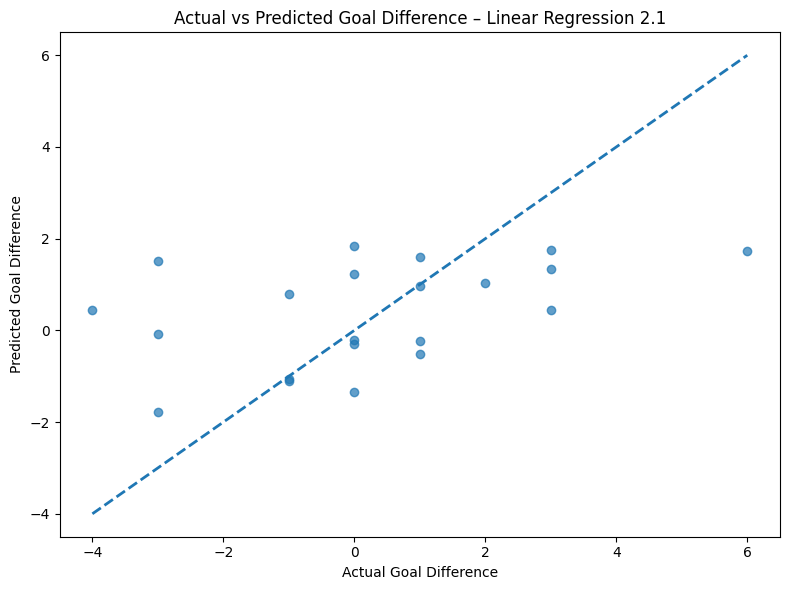

In [29]:
# ACTUAL VS PREDICTED GOAL DIFFERENCE PLOT


plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["Actual_Goal_Difference"],
    comparison["Predicted_Goal_Difference"],
    alpha=0.7
)

# Perfect prediction line
min_value = min(
    comparison["Actual_Goal_Difference"].min(),
    comparison["Predicted_Goal_Difference"].min()
)

max_value = max(
    comparison["Actual_Goal_Difference"].max(),
    comparison["Predicted_Goal_Difference"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Goal Difference")
plt.ylabel("Predicted Goal Difference")

plt.title(
    "Actual vs Predicted Goal Difference – Linear Regression 2.1"
)

plt.tight_layout()
plt.show()

In [30]:
#  RESIDUAL STATISTICS

print("RESIDUAL STATISTICS")


print(
    comparison[
        "Residual"
    ].describe()
)



RESIDUAL STATISTICS
count    21.000000
mean     -0.146300
std       2.168372
min      -4.502490
25%      -1.235235
50%       0.094059
75%       1.246340
max       4.277193
Name: Residual, dtype: float64


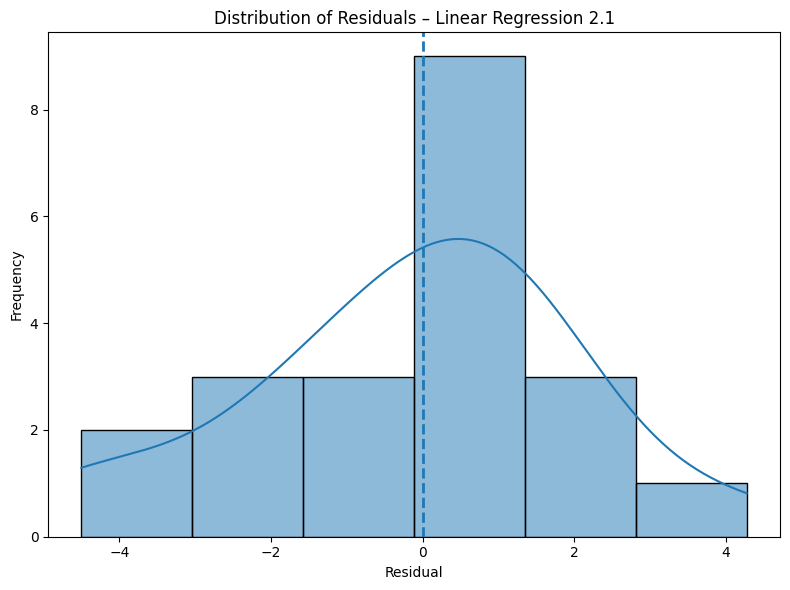

In [31]:
# RESIDUAL DISTRIBUTION PLOT

plt.figure(figsize=(8, 6))

sns.histplot(
    comparison["Residual"],
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Residuals – Linear Regression 2.1"
)

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

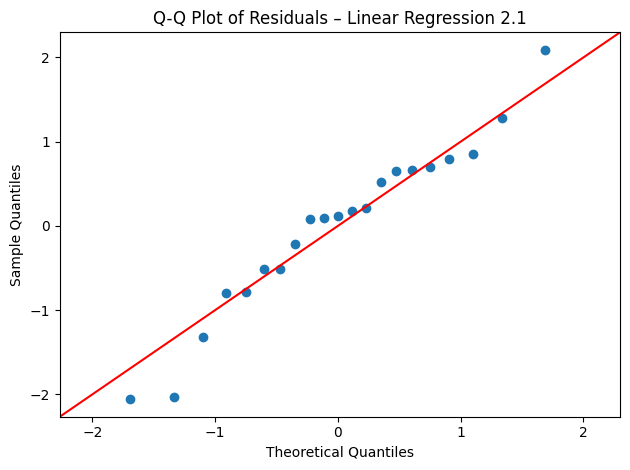

In [32]:
#  Q-Q PLOT OF RESIDUALS

plt.figure(figsize=(8, 6))

sm.qqplot(
    comparison["Residual"],
    line="45",
    fit=True
)

plt.title(
    "Q-Q Plot of Residuals – Linear Regression 2.1"
)

plt.tight_layout()
plt.show()

In [33]:
# SHAPIRO-WILK NORMALITY TEST


print("SHAPIRO-WILK NORMALITY TEST")


shapiro_stat, shapiro_p = shapiro(
    comparison["Residual"]
)

print(
    f"Statistic: {shapiro_stat:.4f}"
)

print(
    f"p-value: {shapiro_p:.4f}"
)

if shapiro_p > 0.05:

    print(
        "Conclusion: Residuals do not "
        "significantly deviate from normality "
        "(p > 0.05)."
    )

else:

    print(
        "Conclusion: Residuals significantly "
        "deviate from normality (p < 0.05)."
    )



SHAPIRO-WILK NORMALITY TEST
Statistic: 0.9618
p-value: 0.5536
Conclusion: Residuals do not significantly deviate from normality (p > 0.05).


In [34]:
#  OLS REGRESSION SIGNIFICANCE

print("OLS REGRESSION SIGNIFICANCE")


X_ols = sm.add_constant(
    X
)

ols_model = sm.OLS(
    y,
    X_ols
).fit()

print(
    ols_model.summary()
)



OLS REGRESSION SIGNIFICANCE
                            OLS Regression Results                            
Dep. Variable:        goal_difference   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     4.580
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           0.000391
Time:                        16:13:12   Log-Likelihood:                -207.43
No. Observations:                 104   AIC:                             428.9
Df Residuals:                      97   BIC:                             447.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
cons

In [35]:
# 95% CONFIDENCE INTERVALS FOR REGRESSION COEFFICIENTS

print("95% CONFIDENCE INTERVALS FOR REGRESSION COEFFICIENTS")

# Extract 95% confidence intervals
confidence_intervals = ols_model.conf_int(alpha=0.05)

# Rename columns
confidence_intervals.columns = [
    "Lower 95%",
    "Upper 95%"
]

# Create coefficient table
coefficient_ci_table = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P-value": ols_model.pvalues.values,
    "Lower 95%": confidence_intervals["Lower 95%"].values,
    "Upper 95%": confidence_intervals["Upper 95%"].values
})

# Round results
coefficient_ci_table = coefficient_ci_table.round(4)

print(
    coefficient_ci_table.to_string(index=False)
)

95% CONFIDENCE INTERVALS FOR REGRESSION COEFFICIENTS
            Variable  Coefficient  P-value  Lower 95%  Upper 95%
               const      15.6195   0.1217    -4.2378    35.4768
      home_fifa_rank      -0.0226   0.1840    -0.0561     0.0109
      away_fifa_rank      -0.0382   0.0242    -0.0713    -0.0051
            home_elo      -0.0025   0.2524    -0.0067     0.0018
            away_elo      -0.0070   0.0028    -0.0115    -0.0025
  home_squad_avg_age      -0.0272   0.8725    -0.3621     0.3078
  away_squad_avg_age       0.1640   0.3282    -0.1672     0.4953
fifa_rank_difference       0.0156   0.1314    -0.0048     0.0360
      elo_difference       0.0045   0.0026     0.0016     0.0074


In [36]:
#  VIF CHECK

print("VARIANCE INFLATION FACTOR (VIF)")


X_vif = X.copy()

vif_table = pd.DataFrame()

vif_table["Variable"] = (
    X_vif.columns
)

vif_table["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(
        X_vif.shape[1]
    )
]

print(
    vif_table
)



VARIANCE INFLATION FACTOR (VIF)
               Variable         VIF
0        home_fifa_rank         inf
1        away_fifa_rank         inf
2              home_elo         inf
3              away_elo         inf
4    home_squad_avg_age  568.644131
5    away_squad_avg_age  601.117319
6  fifa_rank_difference         inf
7        elo_difference         inf


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [37]:
# TWO-SAMPLE T-TEST – DATASET 1
# HOME TEAM WINS VS AWAY TEAM WINS


from scipy.stats import ttest_ind

print("TWO-SAMPLE T-TEST")
print("HOME TEAM WINS VS AWAY TEAM WINS")


# CREATE GROUPS


# Home-team wins: goal difference > 0
home_wins = regression_21.loc[
    regression_21["goal_difference"] > 0,
    "goal_difference"
]

# Away-team wins: goal difference < 0
away_wins = regression_21.loc[
    regression_21["goal_difference"] < 0,
    "goal_difference"
]

# SAMPLE INFORMATION

print(
    "\nNumber of home-team win observations:",
    len(home_wins)
)

print(
    "Number of away-team win observations:",
    len(away_wins)
)

print(
    "\nMean goal difference – home wins:",
    round(home_wins.mean(), 4)
)

print(
    "Mean goal difference – away wins:",
    round(away_wins.mean(), 4)
)

# TWO-SAMPLE T-TEST

t_stat, p_value = ttest_ind(
    home_wins,
    away_wins,
    equal_var=False
)

print("\nTWO-SAMPLE T-TEST RESULTS")

print(
    "T-statistic:",
    round(t_stat, 4)
)

print(
    "P-value:",
    round(p_value, 4)
)

# DECISION


alpha = 0.05

if p_value < alpha:

    print("\nConclusion: Reject H0.")

    print(
        "There is a statistically significant difference "
        "in the mean goal difference between matches won "
        "by the home team and matches won by the away team."
    )

else:

    print("\nConclusion: Fail to reject H0.")

    print(
        "There is insufficient statistical evidence to "
        "conclude that the mean goal difference differs "
        "between home-team wins and away-team wins."
    )

TWO-SAMPLE T-TEST
HOME TEAM WINS VS AWAY TEAM WINS

Number of home-team win observations: 50
Number of away-team win observations: 30

Mean goal difference – home wins: 2.12
Mean goal difference – away wins: -1.8667

TWO-SAMPLE T-TEST RESULTS
T-statistic: 15.2869
P-value: 0.0

Conclusion: Reject H0.
There is a statistically significant difference in the mean goal difference between matches won by the home team and matches won by the away team.


In [38]:
# FIFA WORLD CUP 2026
# LINEAR REGRESSION 2.2
# Predicting Goals Scored by a Team in a Match
# LOAD DATASET

df = pd.read_csv(
    "208_world_cup_dataset.csv"
)

print("DATASET OVERVIEW")

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())



DATASET OVERVIEW
Dataset shape: (208, 11)

First 5 rows:
  match_id          team  home_away  fifa_rank  elo_rating  host_nation  \
0     M001        Mexico          1         14        1810            1   
1     M001  South Africa          0         60        1620            0   
2     M002   South Korea          1         22        1800            0   
3     M002       Czechia          0         40        1740            0   
4     M003        Canada          1         33        1795            1   

   stage  match_number  squad_avg_age  squad_total_value_eur_m  goals_scored  
0      1             1          27.90                   411.91             2  
1      1             1          26.81                    47.70             0  
2      1             2          28.07                   139.05             2  
3      1             2          27.62                   187.14             1  
4      1             3          26.97                   204.23             1  


In [39]:
# DATASET VALIDATION


print("DATASET VALIDATION")

# Number of observations
number_of_observations = len(df)

print("Number of observations:", number_of_observations)

if number_of_observations == 208:
    print(" Dataset contains exactly 208 team-match observations.")
else:
    print(" Dataset does NOT contain exactly 208 observations.")


# Number of unique matches
number_of_matches = df["match_id"].nunique()

print("\nNumber of unique matches:", number_of_matches)

if number_of_matches == 104:
    print(" Dataset contains exactly 104 matches.")
else:
    print(" Dataset does NOT contain exactly 104 matches.")


# Check two teams per match
teams_per_match = df.groupby("match_id")["team"].count()

print("\nTeams per match:")
print(teams_per_match.value_counts())

if (teams_per_match == 2).all():
    print(" Every match contains exactly two team observations.")
else:
    print(" Some matches do not contain exactly two team observations.")


# Check duplicate rows
duplicate_rows = df.duplicated().sum()

print("\nDuplicate rows:", duplicate_rows)

if duplicate_rows == 0:
    print(" No duplicate rows.")
else:
    print(" Duplicate rows detected.")


# Check duplicate match-team combinations
duplicate_match_team = df.duplicated(
    subset=["match_id", "team"]
).sum()

print(
    "Duplicate match-team observations:",
    duplicate_match_team
)

if duplicate_match_team == 0:
    print(" No duplicate match-team observations.")
else:
    print(" Duplicate match-team observations detected.")



DATASET VALIDATION
Number of observations: 208
 Dataset contains exactly 208 team-match observations.

Number of unique matches: 104
 Dataset contains exactly 104 matches.

Teams per match:
team
2    104
Name: count, dtype: int64
 Every match contains exactly two team observations.

Duplicate rows: 0
 No duplicate rows.
Duplicate match-team observations: 0
 No duplicate match-team observations.


In [40]:
#  DATA TYPES AND MISSING VALUES

print("DATA QUALITY CHECK")


print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

DATA QUALITY CHECK

Data types:
match_id                    object
team                        object
home_away                    int64
fifa_rank                    int64
elo_rating                   int64
host_nation                  int64
stage                        int64
match_number                 int64
squad_avg_age              float64
squad_total_value_eur_m    float64
goals_scored                 int64
dtype: object

Missing values:
match_id                   0
team                       0
home_away                  0
fifa_rank                  0
elo_rating                 0
host_nation                0
stage                      0
match_number               0
squad_avg_age              0
squad_total_value_eur_m    0
goals_scored               0
dtype: int64


In [41]:
# DEFINE VARIABLES


# Exactly 8 explanatory variables
predictors = [
    "home_away",
    "fifa_rank",
    "elo_rating",
    "host_nation",
    "stage",
    "match_number",
    "squad_avg_age",
    "squad_total_value_eur_m"
]

# Dependent variable
target = "goals_scored"


print("MODEL VARIABLES")


print("\nNumber of explanatory variables:", len(predictors))

print("\nExplanatory variables:")

for i, variable in enumerate(predictors, 1):
    print(f"{i}. {variable}")

print("\nDependent variable:")
print(target)



MODEL VARIABLES

Number of explanatory variables: 8

Explanatory variables:
1. home_away
2. fifa_rank
3. elo_rating
4. host_nation
5. stage
6. match_number
7. squad_avg_age
8. squad_total_value_eur_m

Dependent variable:
goals_scored


In [42]:
#  VERIFY REQUIRED COLUMNS

required_columns = predictors + [target]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) == 0:

    print("\n All required model columns are available.")

else:

    print("\n Missing required columns:")
    print(missing_columns)

    raise ValueError(
        "Required model columns are missing from the dataset."
    )




 All required model columns are available.


In [43]:
#  PREPARE X AND y

X = df[predictors].copy()

y = df[target].copy()


print("MODEL DATA")


print("X shape:", X.shape)

print("y shape:", y.shape)


if X.shape == (208, 8):

    print(
        " contains exactly 208 observations "
        "and 8 explanatory variables."
    )

else:

    print(" does not have the required shape.")


if y.shape[0] == 208:

    print(" Target contains exactly 208 observations.")

else:

    print(" Target does not contain 208 observations.")

MODEL DATA
X shape: (208, 8)
y shape: (208,)
 contains exactly 208 observations and 8 explanatory variables.
 Target contains exactly 208 observations.


In [44]:
# DESCRIPTIVE STATISTICS


print("DESCRIPTIVE STATISTICS")


descriptive_stats = df[
    predictors + [target]
].describe().T

print(
    descriptive_stats.round(3)
)


DESCRIPTIVE STATISTICS
                         count      mean      std      min      25%       50%  \
home_away                208.0     0.500    0.501     0.00     0.00     0.500   
fifa_rank                208.0    28.260   22.940     1.00     8.75    22.500   
elo_rating               208.0  1839.471  167.936  1510.00  1720.00  1817.500   
host_nation              208.0     0.072    0.259     0.00     0.00     0.000   
stage                    208.0     1.606    1.158     1.00     1.00     1.000   
match_number             208.0    52.500   30.093     1.00    26.75    52.500   
squad_avg_age            208.0    27.867    1.094    25.85    26.97    27.645   
squad_total_value_eur_m  208.0   513.471  514.727    37.91   145.44   357.180   
goals_scored             208.0     1.481    1.393     0.00     0.00     1.000   

                             75%      max  
home_away                   1.00     1.00  
fifa_rank                  44.25    85.00  
elo_rating               1970.00  

In [45]:
# CORRELATION MATRIX

print("CORRELATION MATRIX")

correlation_matrix = df[
    predictors + [target]
].corr()

print(
    correlation_matrix.round(3)
)

CORRELATION MATRIX
                         home_away  fifa_rank  elo_rating  host_nation  stage  \
home_away                    1.000     -0.153       0.170        0.130  0.000   
fifa_rank                   -0.153      1.000      -0.931       -0.084 -0.340   
elo_rating                   0.170     -0.931       1.000       -0.035  0.431   
host_nation                  0.130     -0.084      -0.035        1.000 -0.001   
stage                        0.000     -0.340       0.431       -0.001  1.000   
match_number                 0.000     -0.279       0.338       -0.013  0.719   
squad_avg_age                0.012      0.067      -0.047       -0.156 -0.096   
squad_total_value_eur_m      0.176     -0.689       0.833       -0.097  0.463   
goals_scored                 0.173     -0.353       0.369        0.104  0.040   

                         match_number  squad_avg_age  squad_total_value_eur_m  \
home_away                       0.000          0.012                    0.176   
fifa_ran

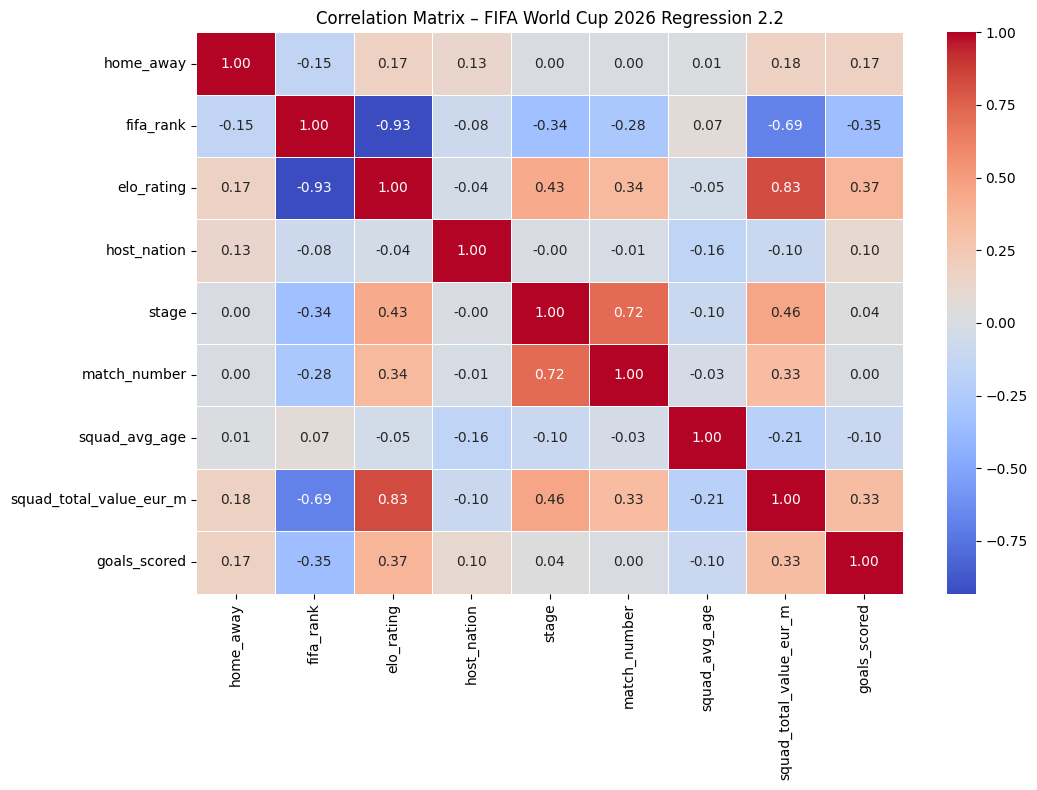

In [46]:
#  CORRELATION HEATMAP

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix – FIFA World Cup 2026 Regression 2.2"
)

plt.tight_layout()

plt.show()

In [47]:
#  TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("TRAIN-TEST SPLIT")

print(
    "Training observations:",
    len(X_train)
)

print(
    "Testing observations:",
    len(X_test)
)

TRAIN-TEST SPLIT
Training observations: 166
Testing observations: 42


In [48]:
# BUILD LINEAR REGRESSION MODEL


model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [49]:
#  MAKE PREDICTIONS

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

In [50]:
#  MODEL EVALUATION


# Training metrics

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    train_mse
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)


# Testing metrics

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    test_mse
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)



print("LINEAR REGRESSION 2.2 PERFORMANCE")



print("\nTRAINING SET")


print(
    "MAE :",
    round(train_mae, 4)
)

print(
    "MSE :",
    round(train_mse, 4)
)

print(
    "RMSE:",
    round(train_rmse, 4)
)

print(
    "R²  :",
    round(train_r2, 4)
)


print("\nTESTING SET")


print(
    "MAE :",
    round(test_mae, 4)
)

print(
    "MSE :",
    round(test_mse, 4)
)

print(
    "RMSE:",
    round(test_rmse, 4)
)

print(
    "R²  :",
    round(test_r2, 4)
)

LINEAR REGRESSION 2.2 PERFORMANCE

TRAINING SET
MAE : 0.9644
MSE : 1.5606
RMSE: 1.2492
R²  : 0.189

TESTING SET
MAE : 0.9311
MSE : 1.6698
RMSE: 1.2922
R²  : 0.1377


In [51]:
#  REGRESSION COEFFICIENTS

coefficients = pd.DataFrame({
    "Variable": predictors,
    "Coefficient": model.coef_
})

coefficients["Absolute_Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("REGRESSION COEFFICIENTS")


print(
    coefficients[
        ["Variable", "Coefficient"]
    ].round(4).to_string(index=False)
)

print(
    "\nIntercept:",
    round(model.intercept_, 4)
)

REGRESSION COEFFICIENTS
               Variable  Coefficient
            host_nation       0.7589
              home_away       0.1911
                  stage      -0.1574
          squad_avg_age      -0.1349
              fifa_rank       0.0059
             elo_rating       0.0040
           match_number      -0.0005
squad_total_value_eur_m       0.0001

Intercept: -2.0693


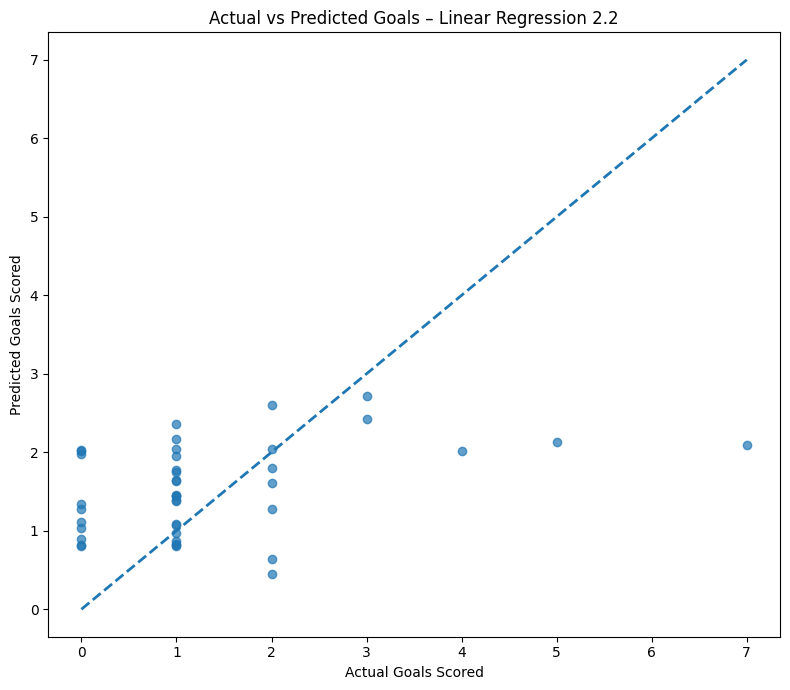

Residuals calculated successfully.
[-0.89697636 -0.44059413  1.3644927  -1.03912611  0.288137    0.13049517
  0.38929711 -0.08385342  4.90395807 -0.95521366]


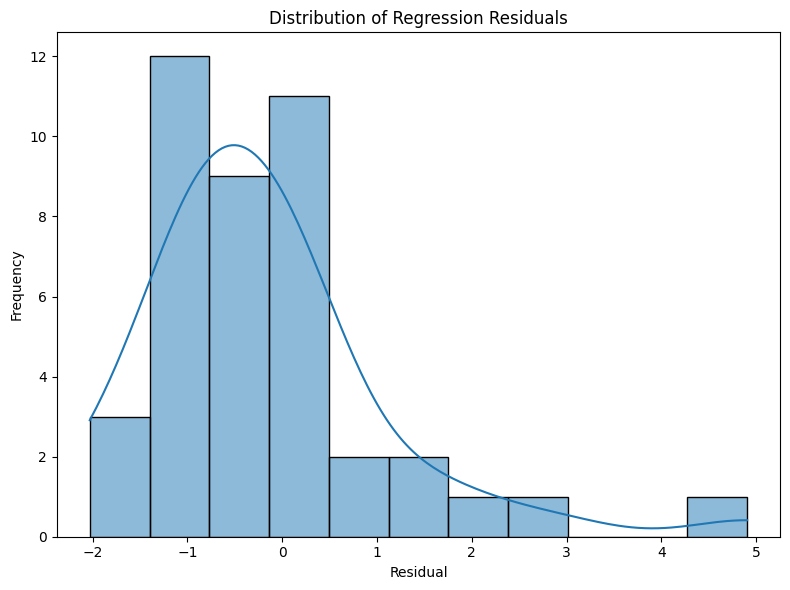

In [52]:
#  ACTUAL VS PREDICTED VALUES

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.7
)

min_value = min(
    np.min(y_test),
    np.min(y_test_pred)
)

max_value = max(
    np.max(y_test),
    np.max(y_test_pred)
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Goals Scored")
plt.ylabel("Predicted Goals Scored")

plt.title(
    "Actual vs Predicted Goals – Linear Regression 2.2"
)

plt.tight_layout()
plt.show()


# RESIDUAL CALCULATION

residuals = (
    np.asarray(y_test)
    - np.asarray(y_test_pred)
)

print("Residuals calculated successfully.")
print(residuals[:10])


#  RESIDUAL DISTRIBUTION


plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Regression Residuals"
)

plt.tight_layout()
plt.show()

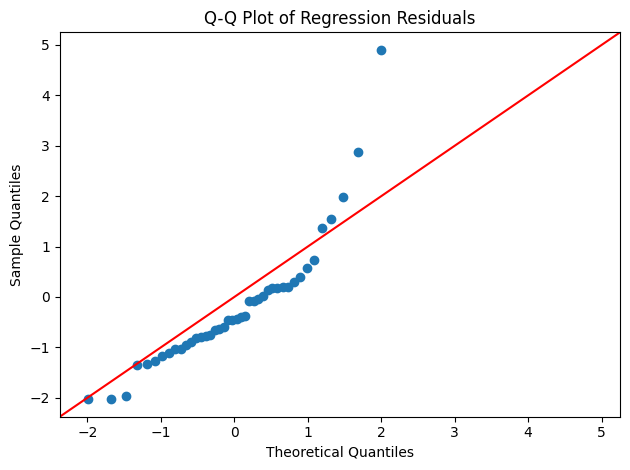

In [53]:
# Q-Q PLOT


sm.qqplot(
    residuals,
    line="45"
)

plt.title(
    "Q-Q Plot of Regression Residuals"
)

plt.tight_layout()

plt.show()


In [54]:
#  OLS STATISTICAL MODEL
X_ols = sm.add_constant(
    X
)
ols_model = sm.OLS(
    y,
    X_ols
).fit()

print("OLS REGRESSION STATISTICAL RESULTS")

print(
    ols_model.summary()
)

OLS REGRESSION STATISTICAL RESULTS
                            OLS Regression Results                            
Dep. Variable:           goals_scored   R-squared:                       0.187
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     5.716
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.50e-06
Time:                        16:13:16   Log-Likelihood:                -342.14
No. Observations:                 208   AIC:                             702.3
Df Residuals:                     199   BIC:                             732.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [55]:
# SHAPIRO-WILK NORMALITY TEST

shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Statistic:", round(shapiro_stat, 4))
print("Shapiro-Wilk p-value:", round(shapiro_p, 4))

Shapiro-Wilk Statistic: 0.8565
Shapiro-Wilk p-value: 0.0001


In [56]:
#  95% CONFIDENCE INTERVALS FOR COEFFICIENTS

confidence_intervals = (
    ols_model.conf_int()
)

confidence_intervals.columns = [
    "Lower 95%",
    "Upper 95%"
]

print("95% CONFIDENCE INTERVALS FOR COEFFICIENTS")


print(
    confidence_intervals.round(4)
)

95% CONFIDENCE INTERVALS FOR COEFFICIENTS
                         Lower 95%  Upper 95%
const                     -11.0665     6.4551
home_away                  -0.1296     0.5973
fifa_rank                  -0.0218     0.0280
elo_rating                 -0.0011     0.0079
host_nation                -0.1565     1.3159
stage                      -0.3669     0.1025
match_number               -0.0117     0.0051
squad_avg_age              -0.2620     0.0892
squad_total_value_eur_m    -0.0005     0.0010


In [57]:
#  VIF – MULTICOLLINEARITY CHECK

X_vif = sm.add_constant(
    X
)

vif_results = pd.DataFrame()

vif_results["Variable"] = (
    X_vif.columns
)

vif_results["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(
        X_vif.shape[1]
    )
]
print("VARIANCE INFLATION FACTOR (VIF)")


print(
    vif_results.round(3).to_string(
        index=False
    )
)

VARIANCE INFLATION FACTOR (VIF)
               Variable      VIF
                  const 2499.739
              home_away    1.076
              fifa_rank   10.585
             elo_rating   18.390
            host_nation    1.181
                  stage    2.395
           match_number    2.087
          squad_avg_age    1.196
squad_total_value_eur_m    4.743


In [58]:
#  PREDICTION RESULTS TABLE


results = pd.DataFrame({
    "match_id": df.loc[
        X_test.index,
        "match_id"
    ],

    "team": df.loc[
        X_test.index,
        "team"
    ],

    "actual_goals": y_test,

    "predicted_goals": y_test_pred
})


results["residual"] = (
    results["actual_goals"]
    - results["predicted_goals"]
)

results["absolute_error"] = (
    results["residual"].abs()
)

results = results.sort_values(
    by="match_id"
)

print("ACTUAL VS PREDICTED RESULTS")


print(
    results.head(20)
    .round(3)
    .to_string(index=False)
)

ACTUAL VS PREDICTED RESULTS
match_id          team  actual_goals  predicted_goals  residual  absolute_error
    M005      Scotland             1            0.870     0.130           0.130
    M008   Switzerland             1            1.441    -0.441           0.441
    M009 Côte d'Ivoire             1            1.651    -0.651           0.651
    M010       Germany             7            2.096     4.904           4.904
    M013       Uruguay             1            1.755    -0.755           0.755
    M016       Belgium             1            2.040    -1.040           1.040
    M023      Congo DR             1            0.812     0.188           0.188
    M033 Côte d'Ivoire             1            1.448    -0.448           0.448
    M034       Ecuador             0            1.975    -1.975           1.975
    M035        Sweden             1            1.390    -0.390           0.390
    M035   Netherlands             5            2.132     2.868           2.868
    M037    

In [59]:
#  FINAL MODEL SUMMARY

print("FINAL REGRESSION 2.2 SUMMARY")


print(
    "Dataset observations:",
    len(df)
)

print(
    "Unique matches:",
    df["match_id"].nunique()
)

print(
    "Explanatory variables:",
    len(predictors)
)

print(
    "Dependent variable:",
    target
)


print("\nExplanatory variables:")

for i, predictor in enumerate(
    predictors,
    1
):
    print(
        f"{i}. {predictor}"
    )


print("\nTest-set performance:")

print(
    "MAE :",
    round(test_mae, 4)
)

print(
    "MSE :",
    round(test_mse, 4)
)

print(
    "RMSE:",
    round(test_rmse, 4)
)

print(
    "R²  :",
    round(test_r2, 4)
)


print("\nOLS statistical results:")

print(
    "OLS R²:",
    round(
        ols_model.rsquared,
        4
    )
)

print(
    "OLS Adjusted R²:",
    round(
        ols_model.rsquared_adj,
        4
    )
)

print(
    "OLS F-statistic:",
    round(
        ols_model.fvalue,
        4
    )
)

print(
    "OLS model p-value:",
    ols_model.f_pvalue
)




FINAL REGRESSION 2.2 SUMMARY
Dataset observations: 208
Unique matches: 104
Explanatory variables: 8
Dependent variable: goals_scored

Explanatory variables:
1. home_away
2. fifa_rank
3. elo_rating
4. host_nation
5. stage
6. match_number
7. squad_avg_age
8. squad_total_value_eur_m

Test-set performance:
MAE : 0.9311
MSE : 1.6698
RMSE: 1.2922
R²  : 0.1377

OLS statistical results:
OLS R²: 0.1868
OLS Adjusted R²: 0.1542
OLS F-statistic: 5.7158
OLS model p-value: 1.4971769903543071e-06


In [60]:
# TWO-SAMPLE T-TEST
# HOME TEAMS VS AWAY TEAMS
# FIFA WORLD CUP 2026 – REGRESSION 2.2


from scipy.stats import ttest_ind

print("TWO-SAMPLE T-TEST")
print("HOME TEAMS VS AWAY TEAMS")


# CREATE TWO INDEPENDENT GROUPS

# home_away = 1 → Home team
# home_away = 0 → Away team

home_goals = df.loc[
    df["home_away"] == 1,
    "goals_scored"
]

away_goals = df.loc[
    df["home_away"] == 0,
    "goals_scored"
]


# GROUP INFORMATION

print("\nNumber of home-team observations:",
      len(home_goals))

print(
    "Number of away-team observations:",
    len(away_goals)
)

print(
    "\nMean home-team goals:",
    round(home_goals.mean(), 4)
)

print(
    "Mean away-team goals:",
    round(away_goals.mean(), 4)
)


# TWO-SAMPLE T-TEST


# H0:
# Mean home-team goals = Mean away-team goals
#
# H1:
# Mean home-team goals != Mean away-team goals

t_stat, p_value = ttest_ind(
    home_goals,
    away_goals,
    equal_var=False
)

# TEST RESULTS


print("\nTWO-SAMPLE T-TEST RESULTS")

print(
    "T-statistic:",
    round(t_stat, 4)
)

print(
    "P-value:",
    round(p_value, 4)
)


# DECISION AT 5% SIGNIFICANCE LEVEL


alpha = 0.05

if p_value < alpha:

    print(
        "\nConclusion: Reject H0."
    )

    print(
        "There is a statistically significant difference "
        "between the average goals scored by home teams "
        "and away teams."
    )

else:

    print(
        "\nConclusion: Fail to reject H0."
    )

    print(
        "There is insufficient statistical evidence to "
        "conclude that the average goals scored by home "
        "teams and away teams are significantly different."
    )

TWO-SAMPLE T-TEST
HOME TEAMS VS AWAY TEAMS

Number of home-team observations: 104
Number of away-team observations: 104

Mean home-team goals: 1.7212
Mean away-team goals: 1.2404

TWO-SAMPLE T-TEST RESULTS
T-statistic: 2.52
P-value: 0.0125

Conclusion: Reject H0.
There is a statistically significant difference between the average goals scored by home teams and away teams.
